# homework 2.4: MLE and linear regression

Aashir Javed | MAT 422

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Aaxhirrr/mat-422-fall-2026/blob/AASHIR/hw2-4/HW2.4/HW2_4_mle_regression.ipynb)

The main question here is how we choose model parameters from a sample. I start with a yes-or-no outcome, then estimate a normal distribution, and finally fit a line. The last example connects maximum likelihood to least squares.

All data below are small, made-up examples for these calculations, not observations from a real study. We can run everything from top to bottom with **Runtime > Run all** in Colab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import norm, linregress

np.set_printoptions(precision=4, suppress=True)

## 2.4.1. MLE for random samples

For an independent, identically distributed sample $x_1,\ldots,x_n$, the likelihood is

$$L(\theta)=\prod_{i=1}^n f(x_i;\theta),\qquad
\ell(\theta)=\log L(\theta)=\sum_{i=1}^n\log f(x_i;\theta).$$

The observations stay fixed while we change $\theta$. The MLE is the parameter value that makes those observations most likely under the model. Taking the log keeps the same maximizer because log is increasing, and a sum is easier to work with than a long product. For continuous data, $f$ is a density, not the probability of seeing one exact value.

### a yes-or-no example

Suppose 1 means a practice question was answered correctly and 0 means it was missed. We model the answers as independent Bernoulli trials with one shared success probability $p$. That is a simplifying assumption: real questions might have different difficulties.

Writing $s=\sum x_i$, we get

$$L(p)=p^s(1-p)^{n-s},\qquad
\ell(p)=s\log p+(n-s)\log(1-p).$$

For $0<s<n$, setting $\ell'(p)=s/p-(n-s)/(1-p)=0$ gives $\hat p=s/n$. The second derivative is negative, so this is a maximum. If every answer is 0 or every answer is 1, the maximum is at the boundary instead.

In [2]:
answers = np.array([1, 0, 1, 1, 0, 1, 1, 1, 0, 1])
n = len(answers)
successes = answers.sum()
p_hat = answers.mean()

def bernoulli_loglik(p):
    return successes * np.log(p) + (n - successes) * np.log1p(-p)

# The search stays inside (0, 1), where the logs are defined.
p_search = minimize_scalar(lambda p: -bernoulli_loglik(p),
                           bounds=(0.001, 0.999), method="bounded")
print(f"correct answers: {successes} out of {n}")
print(f"MLE from the formula: {p_hat:.4f}")
print(f"MLE from a numerical search: {p_search.x:.4f}")
for p in [0.3, 0.5, p_hat, 0.9]:
    print(f"p = {p:.1f}, log-likelihood = {bernoulli_loglik(p):.4f}")

correct answers: 7 out of 10
MLE from the formula: 0.7000
MLE from a numerical search: 0.7000
p = 0.3, log-likelihood = -9.4978
p = 0.5, log-likelihood = -6.9315
p = 0.7, log-likelihood = -6.1086
p = 0.9, log-likelihood = -7.6453


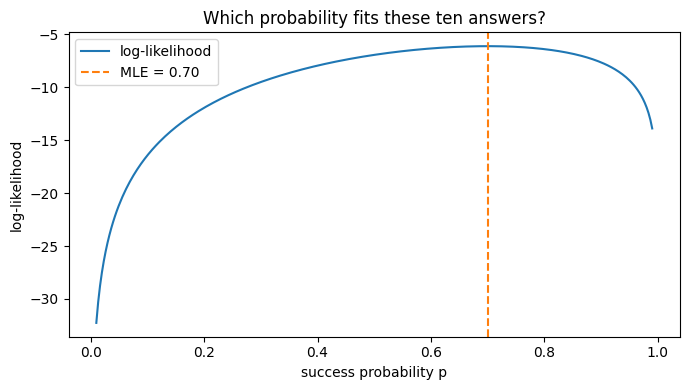

In [3]:
p_values = np.linspace(0.01, 0.99, 300)
plt.figure(figsize=(7, 4))
plt.plot(p_values, bernoulli_loglik(p_values), label="log-likelihood")
plt.axvline(p_hat, color="tab:orange", linestyle="--", label=f"MLE = {p_hat:.2f}")
plt.xlabel("success probability p")
plt.ylabel("log-likelihood")
plt.title("Which probability fits these ten answers?")
plt.legend()
plt.tight_layout()
plt.show()

The peak is at $0.7$, which matches the seven correct answers out of ten. A value such as $0.5$ is possible, but it gives these particular answers a lower likelihood. This does not mean the true success probability has to be exactly $0.7$: another sample could give a different estimate.

### estimating a normal distribution

For a sample from $N(\mu,\sigma^2)$, with $\sigma^2>0$, the log-likelihood is

$$\ell(\mu,\sigma^2)=-\frac n2\log(2\pi\sigma^2)
-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2.$$

Setting its partial derivatives to zero gives

$$\hat\mu=\bar x,\qquad \hat\sigma^2_{\mathrm{MLE}}
=\frac1n\sum_{i=1}^n(x_i-\bar x)^2.$$

The denominator is $n$, not $n-1$. The usual unbiased sample variance uses $n-1$ because we estimated the mean from the same sample. The MLE variance is biased downward: its expectation is $(n-1)\sigma^2/n$. These are different estimation goals, so the two answers should not be forced to match.

In [4]:
# These are hypothetical completion times in minutes.
times = np.array([8, 9, 9, 10, 10, 10, 11, 11, 12, 10], dtype=float)
mu_hat = times.mean()
variance_mle = times.var(ddof=0)
variance_unbiased = times.var(ddof=1)

def normal_nll(parameters):
    mu, log_sigma = parameters
    # Searching over log(sigma) keeps sigma positive.
    return -norm.logpdf(times, loc=mu, scale=np.exp(log_sigma)).sum()

normal_fit = minimize(normal_nll, [9.0, np.log(2.0)], method="BFGS")
print(f"mean MLE: {mu_hat:.4f} minutes")
print(f"variance MLE (divide by n): {variance_mle:.4f}")
print(f"unbiased variance (divide by n - 1): {variance_unbiased:.4f}")
print(f"numerical mean: {normal_fit.x[0]:.4f}")
print(f"numerical variance: {np.exp(2 * normal_fit.x[1]):.4f}")

mean MLE: 10.0000 minutes
variance MLE (divide by n): 1.2000
unbiased variance (divide by n - 1): 1.3333
numerical mean: 10.0000
numerical variance: 1.2000


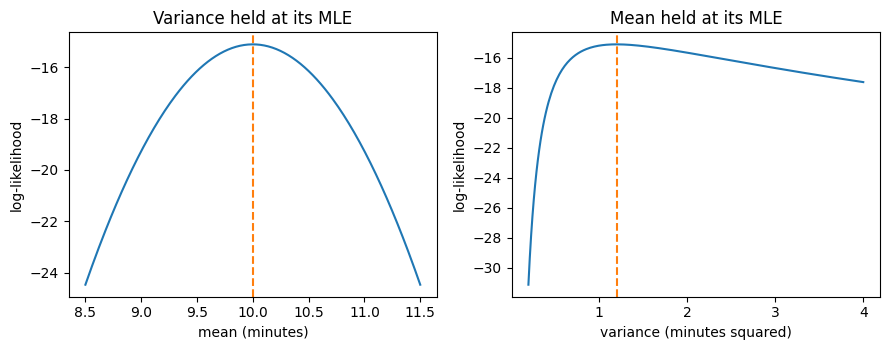

In [5]:
mean_values = np.linspace(8.5, 11.5, 250)
variance_values = np.linspace(0.2, 4, 250)
mean_loglik = [norm.logpdf(times, m, np.sqrt(variance_mle)).sum()
               for m in mean_values]
variance_loglik = [norm.logpdf(times, mu_hat, np.sqrt(v)).sum()
                   for v in variance_values]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].plot(mean_values, mean_loglik)
axes[0].axvline(mu_hat, color="tab:orange", linestyle="--")
axes[0].set(xlabel="mean (minutes)", ylabel="log-likelihood", title="Variance held at its MLE")
axes[1].plot(variance_values, variance_loglik)
axes[1].axvline(variance_mle, color="tab:orange", linestyle="--")
axes[1].set(xlabel="variance (minutes squared)", ylabel="log-likelihood", title="Mean held at its MLE")
plt.tight_layout()
plt.show()

The formula and numerical search both give a mean of 10 minutes and a variance of 1.2 minutes squared. The unbiased variance is about 1.3333, slightly higher. In the plots, we change one parameter while holding the other at its MLE. Both peaks line up with the values from the formulas.

## 2.4.2. linear regression

We can use a line to describe how a response changes with one input:

$$y_i=\beta_0+\beta_1x_i+\varepsilon_i.$$

Here $x$ is study time in hours and $y$ is a practice score out of 100. These are hypothetical scores, so they illustrate the calculation rather than establish a real effect of studying.

Least squares chooses the intercept and slope to minimize

$$\mathrm{SSE}=\sum_{i=1}^n(y_i-\beta_0-\beta_1x_i)^2.$$

When the inputs are not all equal, the solution is

$$\hat\beta_1=\frac{\sum(x_i-\bar x)(y_i-\bar y)}{\sum(x_i-\bar x)^2},
\qquad \hat\beta_0=\bar y-\hat\beta_1\bar x.$$

I calculate the line directly first, then check it against a library result.

In [6]:
hours = np.arange(1, 9, dtype=float)
scores = np.array([52, 55, 61, 63, 69, 72, 78, 80], dtype=float)
slope = np.sum((hours - hours.mean()) * (scores - scores.mean())) / np.sum((hours - hours.mean())**2)
intercept = scores.mean() - slope * hours.mean()
predicted = intercept + slope * hours
residuals = scores - predicted
sse = np.sum(residuals**2)
sst = np.sum((scores - scores.mean())**2)
r_squared = 1 - sse / sst
library_fit = linregress(hours, scores)

print(f"fitted score = {intercept:.4f} + {slope:.4f} * hours")
print(f"SSE: {sse:.4f}")
print(f"training R squared: {r_squared:.4f}")
print(f"predicted score at 4.5 hours: {intercept + slope * 4.5:.4f}")
print("residuals:", residuals)
print("library intercept and slope:", np.round([library_fit.intercept, library_fit.slope], 4))

fitted score = 47.5000 + 4.1667 * hours
SSE: 6.3333
training R squared: 0.9914
predicted score at 4.5 hours: 66.2500
residuals: [ 0.3333 -0.8333  1.     -1.1667  0.6667 -0.5     1.3333 -0.8333]
library intercept and slope: [47.5     4.1667]


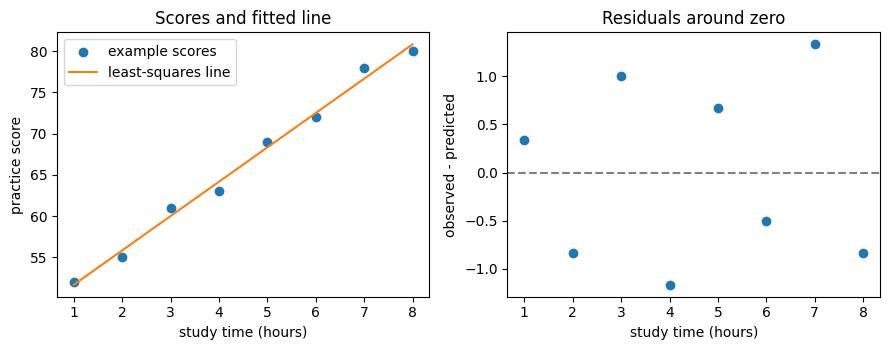

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].scatter(hours, scores, label="example scores")
axes[0].plot(hours, predicted, color="tab:orange", label="least-squares line")
axes[0].set(xlabel="study time (hours)", ylabel="practice score", title="Scores and fitted line")
axes[0].legend()
axes[1].scatter(hours, residuals)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set(xlabel="study time (hours)", ylabel="observed - predicted", title="Residuals around zero")
plt.tight_layout()
plt.show()

The slope is about 4.17 score points per extra hour in this example. At 4.5 hours, the predicted score is 66.25. The intercept describes the fitted score at zero hours, but zero is outside the observed range, so I would not treat that as a supported prediction.

The line fits these constructed points closely. $R^2$ measures the fraction of the observed score variation accounted for by the fitted line, not prediction accuracy on new students. The residuals show the remaining errors. With only eight made-up points, this plot cannot establish normality, independence, or constant error variance. A good fit also does not establish causation.

### why least squares is also an MLE

Now assume the errors are independent $N(0,\sigma^2)$ with the same variance for each observation, conditional on the inputs. Then

$$\ell(\beta_0,\beta_1,\sigma^2)
=-\frac n2\log(2\pi\sigma^2)-\frac{\mathrm{SSE}(\beta_0,\beta_1)}{2\sigma^2}.$$

For any fixed positive variance, maximizing this expression over the line parameters is the same as minimizing SSE. Therefore the normal-error MLE gives the least-squares line, and $\hat\sigma^2=\mathrm{SSE}/n$. An unbiased error variance estimate instead uses $\mathrm{SSE}/(n-2)$ because the line has two estimated coefficients. Least squares itself does not require normal errors; the normality assumption is what gives this likelihood interpretation.

In [8]:
regression_variance = sse / len(hours)
unbiased_error_variance = sse / (len(hours) - 2)

def regression_nll(parameters):
    b0, b1, log_sigma = parameters
    fitted = b0 + b1 * hours
    return -norm.logpdf(scores, fitted, np.exp(log_sigma)).sum()

regression_fit = minimize(regression_nll, [45, 4, np.log(2)], method="BFGS")
print("numerical MLE intercept and slope:", np.round(regression_fit.x[:2], 4))
print(f"error variance MLE: {regression_variance:.4f}")
print(f"numerical error variance: {np.exp(2 * regression_fit.x[2]):.4f}")
print(f"unbiased error variance: {unbiased_error_variance:.4f}")
print(f"SSE for fitted line: {sse:.4f}")
print(f"SSE after increasing the slope by 0.5: {np.sum((scores - (intercept + (slope + 0.5) * hours))**2):.4f}")

numerical MLE intercept and slope: [47.5     4.1667]
error variance MLE: 0.7917
numerical error variance: 0.7917
unbiased error variance: 1.0556
SSE for fitted line: 6.3333
SSE after increasing the slope by 0.5: 57.3333


The numerical likelihood fit returns the same line as least squares. Changing the slope makes SSE larger, so it also lowers the normal log-likelihood when the variance is held fixed. The two error variance estimates differ for the same reason as the normal-sample example: maximizing likelihood and removing finite-sample bias are not the same objective.

## quick checks

These checks compare the formulas, numerical searches, and regression identities. Small tolerances allow for rounding in the optimization. They check the calculations, not whether the modeling assumptions would hold for real data.

In [9]:
checks = {
    "Bernoulli MLE is 0.7": np.isclose(p_hat, 0.7),
    "Bernoulli search agrees": p_search.success and np.isclose(p_search.x, p_hat, atol=1e-5),
    "normal mean and variance agree": np.allclose([mu_hat, variance_mle], [10, 1.2]),
    "normal search agrees": np.allclose([normal_fit.x[0], np.exp(2 * normal_fit.x[1])], [mu_hat, variance_mle], atol=1e-4),
    "variance correction agrees": np.isclose(variance_unbiased, variance_mle * len(times) / (len(times) - 1)),
    "regression agrees with library": np.allclose([intercept, slope], [library_fit.intercept, library_fit.slope]),
    "residuals sum to zero": np.isclose(residuals.sum(), 0, atol=1e-10),
    "residuals are orthogonal to input": np.isclose(hours @ residuals, 0, atol=1e-10),
    "regression MLE agrees": np.allclose(regression_fit.x[:2], [intercept, slope], atol=1e-4),
    "error variance MLE agrees": np.isclose(np.exp(2 * regression_fit.x[2]), regression_variance, atol=1e-4),
    "R squared matches correlation squared": np.isclose(r_squared, library_fit.rvalue**2),
}
for label, passed in checks.items():
    print(f"{label}: {bool(passed)}")
assert all(checks.values()), "one of the checks needs another look"

Bernoulli MLE is 0.7: True
Bernoulli search agrees: True
normal mean and variance agree: True
normal search agrees: True
variance correction agrees: True
regression agrees with library: True
residuals sum to zero: True
residuals are orthogonal to input: True
regression MLE agrees: True
error variance MLE agrees: True
R squared matches correlation squared: True


## what I took from this

MLE starts with a probability model and asks which parameters best fit the observed sample. For Bernoulli data, that leads to the observed success rate. For normal data, it leads to the sample mean and a variance with denominator n. We also get the least-squares regression line from likelihood once we assume independent normal errors with a shared variance. The assumptions matter: a calculation can be correct even when the model is not a good description of real data.

- AI use note: I had help from Codex in refining the code (not completely writing it), refining the latex of the report, and pushing it to GitHub. Other than that, the intial psuedocode/boilerplates, logic, and the report is still drafted by me. I ran every cell and reviewed the math and explanations before submitting.